# CS224N L01 Code Capsule: One-hot vs Dense Word Vectors

**Waypoint**: WP01 — 为什么需要词向量？

**Official anchor**: Slides p19-22; Notes §2.2 (one-hot vectors, Eq.1-2)

## 核心问题

Slides p20 说：*"There is no natural notion of similarity for one-hot vectors!"*

这个 capsule 用代码证明：
1. One-hot 向量之间点积全为 0（正交）→ 无法编码相似性
2. Dense 向量让相似词（hotel/motel）有高余弦相似度

## 运行环境

只需要 `numpy` 和 `matplotlib`（Colab 自带）。

### 🔍 这段代码在看什么

本 capsule 演示 **one-hot 向量 vs 密集（dense）词向量** 的核心差异——这正是 CS224N Lecture 1 Slides p19-22 讲的关键问题。

**核心问题**：one-hot 编码下，任意两个不同词的余弦相似度都是 0（完全正交），无法表达"hotel"和"motel"很相似这种关系。而 dense 向量可以让语义相近的词在向量空间中距离更近。

你将看到：
- Part 1-2：one-hot 编码和它的余弦相似度矩阵（全部为 0）
- Part 3：手构造的 dense 向量如何编码相似性
- Part 4：可视化对比


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Tiny vocabulary from CS224N slides examples
vocab = ["hotel", "motel", "book", "Seattle", "Seattle_motel"]
vocab_size = len(vocab)
print(f"Vocabulary ({vocab_size} words): {vocab}")

Vocabulary (5 words): ['hotel', 'motel', 'book', 'Seattle', 'Seattle_motel']


## Part 1: One-hot Encoding

每个词一个位置为 1，其余为 0。维度 = 词汇量。

In [2]:
one_hot = np.eye(vocab_size)

for i, word in enumerate(vocab):
    print(f"  {word:15s} → {one_hot[i].tolist()}")

print(f"\nDimension = {vocab_size}, Sparsity = {(1 - one_hot.sum() / one_hot.size) * 100:.1f}%")

  hotel           → [1.0, 0.0, 0.0, 0.0, 0.0]
  motel           → [0.0, 1.0, 0.0, 0.0, 0.0]
  book            → [0.0, 0.0, 1.0, 0.0, 0.0]
  Seattle         → [0.0, 0.0, 0.0, 1.0, 0.0]
  Seattle_motel   → [0.0, 0.0, 0.0, 0.0, 1.0]

Dimension = 5, Sparsity = 80.0%


## Part 2: One-hot 点积 = 0（正交）

关键观察：任意两个不同词的 one-hot 向量点积都是 0。

In [3]:
dot_matrix_onehot = one_hot @ one_hot.T
norms = np.linalg.norm(one_hot, axis=1)
cos_matrix_onehot = dot_matrix_onehot / np.outer(norms, norms)

print("Cosine similarity (one-hot):")
print(f"{'':15s}", end="")
for w in vocab: print(f"{w:>15s}", end="")
print()
for i, wi in enumerate(vocab):
    print(f"{wi:15s}", end="")
    for j in range(vocab_size):
        print(f"{cos_matrix_onehot[i,j]:15.1f}", end="")
    print()

print(f"\n⚠️  cos(hotel, motel) = {cos_matrix_onehot[0,1]:.1f}  ← 正交！无法区分相似词")

Cosine similarity (one-hot):
                         hotel          motel           book        Seattle  Seattle_motel
hotel                      1.0            0.0            0.0            0.0            0.0
motel                      0.0            1.0            0.0            0.0            0.0
book                       0.0            0.0            1.0            0.0            0.0
Seattle                    0.0            0.0            0.0            1.0            0.0
Seattle_motel              0.0            0.0            0.0            0.0            1.0

⚠️  cos(hotel, motel) = 0.0  ← 正交！无法区分相似词


### 👀 运行后先看哪里

运行完 Part 2 的代码后，**先看 one-hot 的余弦相似度矩阵**：

- `cos(hotel, motel) = 0.0` — 这两个词在现实中非常相似，但 one-hot 完全无法表达
- `cos(hotel, book) = 0.0` — hotel 和 book 不相似，也是 0

**所有不同词对的 cos 都是 0**，这就是 one-hot 的根本缺陷：它把所有词都放在等距离的正交方向上，没有任何"相似"的概念。


## Part 3: Dense Word Vectors

Slides p21-22: *"We will build a dense vector for each word"*

这里用手构造的 3D 向量演示核心思想：相似词 → 相似向量 → 高余弦相似度。

In [4]:
dense_vectors = np.array([
    [0.9,  0.1,  0.2],   # hotel
    [0.8,  0.2,  0.1],   # motel (similar to hotel)
    [0.1,  0.9,  0.3],   # book (different)
    [0.2,  0.3,  0.9],   # Seattle (location)
    [0.5,  0.2,  0.6],   # Seattle_motel (mix)
])

dot_dense = dense_vectors @ dense_vectors.T
norms_dense = np.linalg.norm(dense_vectors, axis=1)
cos_dense = dot_dense / np.outer(norms_dense, norms_dense)

print("Cosine similarity (dense):")
print(f"{'':15s}", end="")
for w in vocab: print(f"{w:>15s}", end="")
print()
for i, wi in enumerate(vocab):
    print(f"{wi:15s}", end="")
    for j in range(vocab_size):
        print(f"{cos_dense[i,j]:15.3f}", end="")
    print()

print(f"\n✅ cos(hotel, motel) = {cos_dense[0,1]:.3f}  ← 高相似度！")
print(f"✅ cos(hotel, book)  = {cos_dense[0,2]:.3f}  ← 低相似度")

Cosine similarity (dense):
                         hotel          motel           book        Seattle  Seattle_motel
hotel                    1.000          0.987          0.271          0.434          0.789
motel                    0.987          1.000          0.366          0.385          0.747
book                     0.271          0.366          1.000          0.605          0.533
Seattle                  0.434          0.385          0.605          1.000          0.896
Seattle_motel            0.789          0.747          0.533          0.896          1.000

✅ cos(hotel, motel) = 0.987  ← 高相似度！
✅ cos(hotel, book)  = 0.271  ← 低相似度


### 📖 输出怎么解释

Part 3 的 dense 向量结果完全不同：

| 词对 | cos 相似度 | 含义 |
|------|-----------|------|
| hotel ↔ motel | **0.987** | 非常高的相似度（接近 1），符合直觉 |
| hotel ↔ book | **0.271** | 较低的相似度，这两个词确实不太相关 |

**关键对比**：
- one-hot: cos(hotel, motel) = **0.0** → 完全无法区分"相似"和"不相似"
- dense: cos(hotel, motel) = **0.987** vs cos(hotel, book) = **0.271** → 成功编码了语义相似性

这就是为什么 NLP 需要 dense word vectors 而不是 one-hot。


## Part 4: 可视化对比

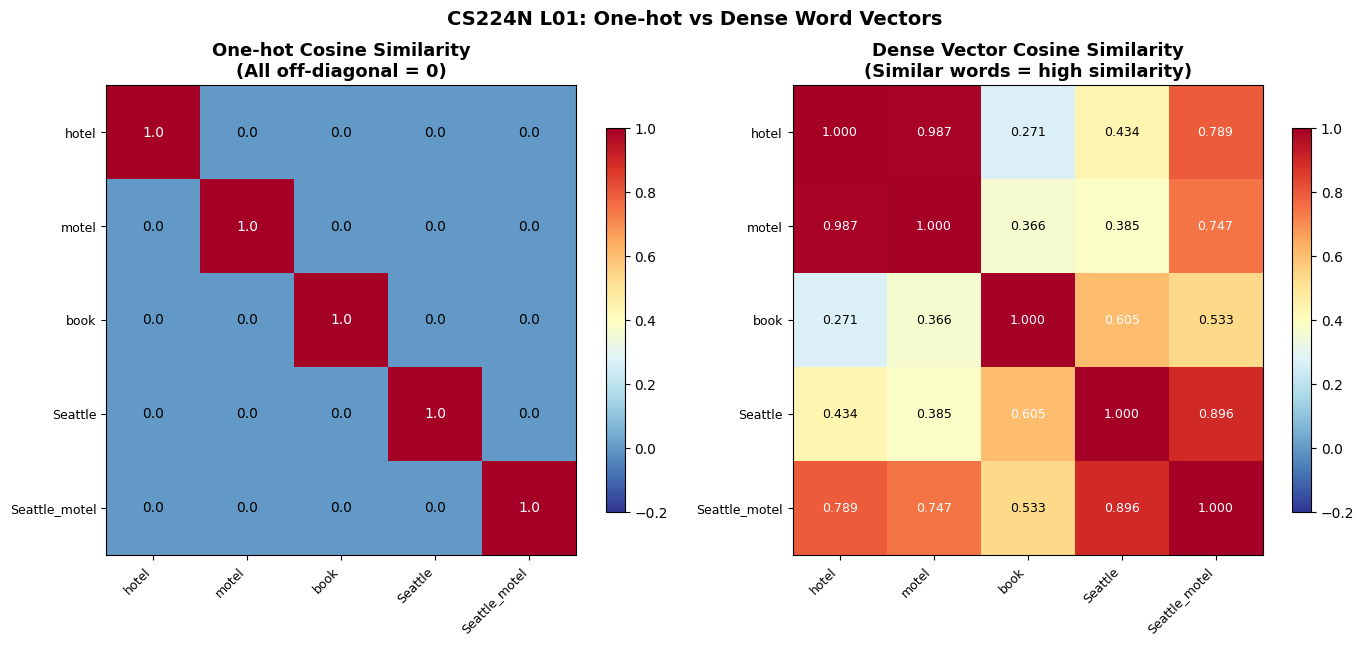

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: one-hot heatmap
im1 = axes[0].imshow(cos_matrix_onehot, cmap='RdYlBu_r', vmin=-0.2, vmax=1.0)
axes[0].set_title("One-hot Cosine Similarity\n(All off-diagonal = 0)", fontsize=13, fontweight='bold')
axes[0].set_xticks(range(vocab_size)); axes[0].set_yticks(range(vocab_size))
axes[0].set_xticklabels(vocab, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(vocab, fontsize=9)
for i in range(vocab_size):
    for j in range(vocab_size):
        axes[0].text(j, i, f"{cos_matrix_onehot[i,j]:.1f}", ha="center", va="center", fontsize=10,
                    color="white" if cos_matrix_onehot[i,j] > 0.5 else "black")
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# Right: dense heatmap
im2 = axes[1].imshow(cos_dense, cmap='RdYlBu_r', vmin=-0.2, vmax=1.0)
axes[1].set_title("Dense Vector Cosine Similarity\n(Similar words = high similarity)", fontsize=13, fontweight='bold')
axes[1].set_xticks(range(vocab_size)); axes[1].set_yticks(range(vocab_size))
axes[1].set_xticklabels(vocab, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(vocab, fontsize=9)
for i in range(vocab_size):
    for j in range(vocab_size):
        axes[1].text(j, i, f"{cos_dense[i,j]:.3f}", ha="center", va="center", fontsize=9,
                    color="white" if cos_dense[i,j] > 0.6 else "black")
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle("CS224N L01: One-hot vs Dense Word Vectors", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

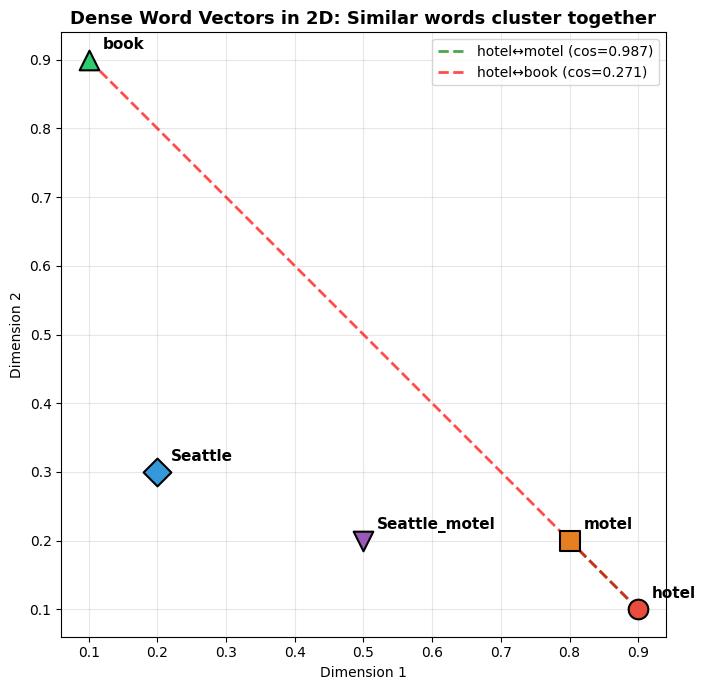

In [6]:
fig2, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']
markers = ['o', 's', '^', 'D', 'v']

for i, word in enumerate(vocab):
    ax.scatter(dense_vectors[i,0], dense_vectors[i,1], c=colors[i], marker=markers[i],
              s=200, zorder=5, edgecolors='black', linewidth=1.5)
    ax.annotate(word, (dense_vectors[i,0], dense_vectors[i,1]),
               textcoords="offset points", xytext=(10,8), fontsize=11, fontweight='bold')

ax.plot([dense_vectors[0,0], dense_vectors[1,0]], [dense_vectors[0,1], dense_vectors[1,1]],
       'g--', lw=2, alpha=0.7, label=f'hotel↔motel (cos={cos_dense[0,1]:.3f})')
ax.plot([dense_vectors[0,0], dense_vectors[2,0]], [dense_vectors[0,1], dense_vectors[2,1]],
       'r--', lw=2, alpha=0.7, label=f'hotel↔book (cos={cos_dense[0,2]:.3f})')

ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
ax.set_title("Dense Word Vectors in 2D: Similar words cluster together", fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 🎯 和本讲哪个 waypoint 对应

本 capsule 对应 **WP01: 为什么需要词向量？**

WP01 的核心问题是：为什么不能用简单的 one-hot 编码来表示词？本 capsule 通过实际计算回答了这个问题的两个方面：
1. **one-hot 的失败**：所有词对 cos = 0，无法编码相似性
2. **dense 向量的成功**：相似词（hotel/motel）cos ≈ 0.99，不相似词（hotel/book）cos ≈ 0.27

这正是 Slides p19-22 和 Notes §2.2 要传达的核心思想。


## 总结

| 对比项 | One-hot | Dense |
|--------|---------|-------|
| cos(hotel, motel) | 0.0 | 0.987 |
| cos(hotel, book) | 0.0 | 0.271 |
| 维度 | = 词汇量 (50,000+) | 低维 (50-300) |
| 稀疏度 | 100% 零 | 0% 零 |

**Takeaway** (Slides p21-22): Dense vectors 从数据中学习，低维、密集、能编码语义相似性。
这是 Word2Vec 的基础（下一个 capsule）。

### ⚠️ 容易误解的地方

1. **本 capsule 的 dense 向量是手构造的演示数据**，不是从语料库学来的。真实的词向量（如 Word2Vec、GloVe）是通过大量文本训练得到的，能自动捕捉语义关系。

2. **3D 只是为了可视化**。真实词向量通常是 50-300 维（CS224N 后面会用到 300 维）。3D 让我们能画散点图，但核心数学（余弦相似度计算）在高维完全一样。

3. **cos = 0.987 不代表"完全相同"**。余弦相似度 1.0 才是完全相同方向。0.987 表示 hotel 和 motel 非常相似但不完全一样——这恰好符合现实：motel = motor + hotel，有细微差别。

4. **稀疏性差异**：one-hot 的稀疏度是 `(V-1)/V × 100%`（本例 V=5，稀疏度 80%），维度越大越稀疏；dense 向量每个维度都有非零值。
